### Classification and Regression Trees

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

SEED = 1

# load the breast cancer dataset
cancer = load_breast_cancer()

# get the indices of the two features we want to use
feature_indices = [
    list(cancer.feature_names).index('mean radius'),
    list(cancer.feature_names).index('mean concave points')
]
X = cancer.data[:, feature_indices]

# get the target variable and convert it to binary (0 for malignant, 1 for benign)
y = (cancer.target == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (455, 2)
X_test shape: (114, 2)


In [21]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print(y_pred[0:5])

[1 0 0 1 0]


In [22]:
# Import accuracy score metric
from sklearn.metrics import accuracy_score

y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.88


#### Logistic Regression vs Classification Tree

In [23]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Define SEED for reproducibility
SEED = 1

# Load the dataset
cancer = load_breast_cancer()

# Select the required features ('mean radius' and 'mean concave points')
feature_indices = [
    list(cancer.feature_names).index('mean radius'),
    list(cancer.feature_names).index('mean concave points')
]
feature_names = ['radius_mean', 'concave points_mean']

X_df = pd.DataFrame(cancer.data[:, feature_indices], columns=feature_names)

# Format target labels (Class 1: malignant, Class 0: benign)
# Note: Sklearn's default is 0 for malignant and 1 for benign, so we invert it to match the prompt.
y_series = pd.Series((cancer.target == 0).astype(int), name='target')

# Split into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_series, test_size=0.2, random_state=SEED
)

In [25]:
# From DataCamp
def plot_labeled_decision_regions(X,y, models):    
    '''
    Function producing a scatter plot of the instances contained 
    in the 2D dataset (X,y) along with the decision 
    regions of two trained classification models contained in the
    list 'models'.
            
    Parameters
    ----------
    X: pandas DataFrame corresponding to two numerical features 
    y: pandas Series corresponding the class labels
    models: list containing two trained classifiers 
    
    '''
    if len(models) != 2:
        raise Exception('''
        Models should be a list containing only two trained classifiers.
        ''')
    if not isinstance(X, pd.DataFrame):
        raise Exception('''
        X has to be a pandas DataFrame with two numerical features.
        ''')
    if not isinstance(y, pd.Series):
        raise Exception('''
        y has to be a pandas Series corresponding to the labels.
        ''')
    fig, ax = plt.subplots(1, 2, figsize=(6.0,2.7), sharey=True)
    for i, model in enumerate(models):
        plot_decision_regions(X.values,y.values, model, legend= 2, ax = ax[i])
        ax[i].set_title(model.__class__.__name__)
        ax[i].set_xlabel(X.columns[0])
        if i == 0:
            ax[i].set_ylabel(X.columns[1])
        ax[i].set_ylim(X.values[:,1].min(), X.values[:,1].max())
        ax[i].set_xlim(X.values[:,0].min(), X.values[:,0].max())
    plt.tight_layout()
    plt.show()

In [39]:
from mlxtend.utils import check_Xy
from itertools import cycle
from math import floor, ceil
from mlxtend.utils import format_kwarg_dictionaries
def plot_decision_regions(X, y, clf,
                          feature_index=None,
                          filler_feature_values=None,
                          filler_feature_ranges=None,
                          ax=None,
                          X_highlight=None,
                          zoom_factor=1.,
                          legend=1,
                          hide_spines=True,
                          markers='s^oxv<>',
                          colors=('#1f77b4,#ff7f0e,#3ca02c,#d62728,'
                                  '#9467bd,#8c564b,#e377c2,'
                                  '#7f7f7f,#bcbd22,#17becf'),
                          scatter_kwargs=None,
                          contourf_kwargs=None,
                          scatter_highlight_kwargs=None):
    """Plot decision regions of a classifier.

    Please note that this functions assumes that class labels are
    labeled consecutively, e.g,. 0, 1, 2, 3, 4, and 5. If you have class
    labels with integer labels > 4, you may want to provide additional colors
    and/or markers as `colors` and `markers` arguments.
    See http://matplotlib.org/examples/color/named_colors.html for more
    information.

    Parameters
    ----------
    X : array-like, shape = [n_samples, n_features]
        Feature Matrix.

    y : array-like, shape = [n_samples]
        True class labels.

    clf : Classifier object.
        Must have a .predict method.

    feature_index : array-like (default: (0,) for 1D, (0, 1) otherwise)
        Feature indices to use for plotting. The first index in
        `feature_index` will be on the x-axis, the second index will be
        on the y-axis.

    filler_feature_values : dict (default: None)
        Only needed for number features > 2. Dictionary of feature
        index-value pairs for the features not being plotted.

    filler_feature_ranges : dict (default: None)
        Only needed for number features > 2. Dictionary of feature
        index-value pairs for the features not being plotted. Will use the
        ranges provided to select training samples for plotting.

    ax : matplotlib.axes.Axes (default: None)
        An existing matplotlib Axes. Creates
        one if ax=None.

    X_highlight : array-like, shape = [n_samples, n_features] (default: None)
        An array with data points that are used to highlight samples in `X`.

    zoom_factor : float (default: 1.0)
        Controls the scale of the x- and y-axis of the decision plot.

    hide_spines : bool (default: True)
        Hide axis spines if True.

    legend : int (default: 1)
        Integer to specify the legend location.
        No legend if legend is 0.

    markers : str (default: 's^oxv<>')
        Scatterplot markers.

    colors : str (default: 'red,blue,limegreen,gray,cyan')
        Comma separated list of colors.

    scatter_kwargs : dict (default: None)
        Keyword arguments for underlying matplotlib scatter function.

    contourf_kwargs : dict (default: None)
        Keyword arguments for underlying matplotlib contourf function.

    scatter_highlight_kwargs : dict (default: None)
        Keyword arguments for underlying matplotlib scatter function.

    Returns
    ---------
    ax : matplotlib.axes.Axes object

    Examples
    -----------
    For usage examples, please see
    http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/

    """

    check_Xy(X, y, y_int=True)  # Validate X and y arrays
    dim = X.shape[1]

    if ax is None:
        ax = plt.gca()

    plot_testdata = True
    if not isinstance(X_highlight, np.ndarray):
        if X_highlight is not None:
            raise ValueError('X_highlight must be a NumPy array or None')
        else:
            plot_testdata = False
    elif len(X_highlight.shape) < 2:
        raise ValueError('X_highlight must be a 2D array')

    if feature_index is not None:
        # Unpack and validate the feature_index values
        if dim == 1:
            raise ValueError(
                'feature_index requires more than one training feature')
        try:
            x_index, y_index = feature_index
        except ValueError:
            raise ValueError(
                'Unable to unpack feature_index. Make sure feature_index '
                'only has two dimensions.')
        try:
            X[:, x_index], X[:, y_index]
        except IndexError:
            raise IndexError(
                'feature_index values out of range. X.shape is {}, but '
                'feature_index is {}'.format(X.shape, feature_index))
    else:
        feature_index = (0, 1)
        x_index, y_index = feature_index

    # Extra input validation for higher number of training features
    if dim > 2:
        if filler_feature_values is None:
            raise ValueError('Filler values must be provided when '
                             'X has more than 2 training features.')

        if filler_feature_ranges is not None:
            if not set(filler_feature_values) == set(filler_feature_ranges):
                raise ValueError(
                    'filler_feature_values and filler_feature_ranges must '
                    'have the same keys')

        # Check that all columns in X are accounted for
        column_check = np.zeros(dim, dtype=bool)
        for idx in filler_feature_values:
            column_check[idx] = True
        for idx in feature_index:
            column_check[idx] = True
        if not all(column_check):
            missing_cols = np.argwhere(~column_check).flatten()
            raise ValueError(
                'Column(s) {} need to be accounted for in either '
                'feature_index or filler_feature_values'.format(missing_cols))

    marker_gen = cycle(list(markers))

    n_classes = np.unique(y).shape[0]
    colors = colors.split(',')
    colors_gen = cycle(colors)
    colors = [next(colors_gen) for c in range(n_classes)]

    # Get minimum and maximum
    x_min, x_max = (X[:, x_index].min() - 1./zoom_factor,
                    X[:, x_index].max() + 1./zoom_factor)
    if dim == 1:
        y_min, y_max = -1, 1
    else:
        y_min, y_max = (X[:, y_index].min() - 1./zoom_factor,
                        X[:, y_index].max() + 1./zoom_factor)

    xnum, ynum = plt.gcf().dpi * plt.gcf().get_size_inches()
    xnum, ynum = floor(xnum), ceil(ynum)
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, num=xnum),
                         np.linspace(y_min, y_max, num=ynum))

    if dim == 1:
        X_predict = np.array([xx.ravel()]).T
    else:
        X_grid = np.array([xx.ravel(), yy.ravel()]).T
        X_predict = np.zeros((X_grid.shape[0], dim))
        X_predict[:, x_index] = X_grid[:, 0]
        X_predict[:, y_index] = X_grid[:, 1]
        if dim > 2:
            for feature_idx in filler_feature_values:
                X_predict[:, feature_idx] = filler_feature_values[feature_idx]
    Z = clf.predict(X_predict.astype(X.dtype))
    Z = Z.reshape(xx.shape)
    # Plot decisoin region
    # Make sure contourf_kwargs has backwards compatible defaults
    contourf_kwargs_default = {'alpha': 0.45, 'antialiased': True}
    contourf_kwargs = format_kwarg_dictionaries(
                        default_kwargs=contourf_kwargs_default,
                        user_kwargs=contourf_kwargs,
                        protected_keys=['colors', 'levels'])
    cset = ax.contourf(xx, yy, Z,
                       colors=colors,
                       levels=np.arange(Z.max() + 2) - 0.5,
                       **contourf_kwargs)

    ax.contour(xx, yy, Z, cset.levels,
               colors='k',
               linewidths=0.5,
               antialiased=True)

    ax.axis([xx.min(), xx.max(), yy.min(), yy.max()])

    # Scatter training data samples
    # Make sure scatter_kwargs has backwards compatible defaults
    scatter_kwargs_default = {'alpha': 0.8, 'edgecolor': 'black'}
    scatter_kwargs = format_kwarg_dictionaries(
                        default_kwargs=scatter_kwargs_default,
                        user_kwargs=scatter_kwargs,
                        protected_keys=['c', 'marker', 'label'])
    for idx, c in enumerate(np.unique(y)):
        if dim == 1:
            y_data = [0 for i in X[y == c]]
            x_data = X[y == c]
        elif dim == 2:
            y_data = X[y == c, y_index]
            x_data = X[y == c, x_index]
        elif dim > 2 and filler_feature_ranges is not None:
            class_mask = y == c
            feature_range_mask = get_feature_range_mask(
                            X, filler_feature_values=filler_feature_values,
                            filler_feature_ranges=filler_feature_ranges)
            y_data = X[class_mask & feature_range_mask, y_index]
            x_data = X[class_mask & feature_range_mask, x_index]
        else:
            continue

        ax.scatter(x=x_data,
                   y=y_data,
                   c=colors[idx],
                   marker=next(marker_gen),
                   label=c,
                   **scatter_kwargs)

    if hide_spines:
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    if dim == 1:
        ax.axes.get_yaxis().set_ticks([])

    if plot_testdata:
        if dim == 1:
            x_data = X_highlight
            y_data = [0 for i in X_highlight]
        elif dim == 2:
            x_data = X_highlight[:, x_index]
            y_data = X_highlight[:, y_index]
        else:
            feature_range_mask = get_feature_range_mask(
                    X_highlight, filler_feature_values=filler_feature_values,
                    filler_feature_ranges=filler_feature_ranges)
            y_data = X_highlight[feature_range_mask, y_index]
            x_data = X_highlight[feature_range_mask, x_index]

        # Make sure scatter_highlight_kwargs backwards compatible defaults
        scatter_highlight_defaults = {'c': 'none',
                                      'edgecolor': 'black',
                                      'alpha': 1.0,
                                      'linewidths': 1,
                                      'marker': 'o',
                                      's': 80}
        scatter_highlight_kwargs = format_kwarg_dictionaries(
                                    default_kwargs=scatter_highlight_defaults,
                                    user_kwargs=scatter_highlight_kwargs)
        ax.scatter(x_data,
                   y_data,
                   **scatter_highlight_kwargs)

    if legend:
        if dim > 2 and filler_feature_ranges is None:
            pass
        else:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels,
                      framealpha=0.3, scatterpoints=1, loc=legend)

    return ax

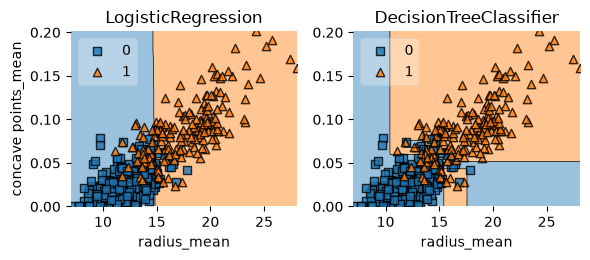

In [41]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train.values, y_train)

classifiers = [logreg, dt]

plot_labeled_decision_regions(X_train, y_train, classifiers)

#### Classification Tree Learning

In [43]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=8)
dt_entropy.fit(X_train, y_train)

dt_gini = DecisionTreeClassifier(criterion='gini', random_state=1, max_depth=8)
dt_gini.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in 

In [45]:
from sklearn.metrics import accuracy_score

y_pred_entropy = dt_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

y_pred_gini = dt_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)

print(f"Accuracy (Entropy): {accuracy_entropy:.4f}")
print(f"Accuracy (Gini): {accuracy_gini:.4f}")

Accuracy (Entropy): 0.8947
Accuracy (Gini): 0.8860


### Decision Tree Regressor

In [60]:
# Load auto-mpg dataset
df = pd.read_csv("data/auto-mpg.csv")

# drop rows with missing values
df = df.replace('?', np.nan)
df = df.dropna()

X = df.drop(columns = ["mpg", "origin", "car name"]).values
y = df["mpg"].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)


In [61]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=SEED, max_depth=8, min_samples_leaf=0.13)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",0.13
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with 

In [62]:
from sklearn.metrics import root_mean_squared_error as RMSE

y_pred = dt.predict(X_test)

rmse_dt = RMSE(y_test, y_pred)
print(f"RMSE (Decision Tree): {rmse_dt:.4f}")

RMSE (Decision Tree): 4.3163


In [66]:
# Linear Regression vs Decision Tree Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
rmse_lr = RMSE(y_test, y_pred_lr)

print(f"RMSE (Linear Regression): {rmse_lr:.4f}")
print(f"RMSE (Decision Tree): {rmse_dt:.4f}")

RMSE (Linear Regression): 3.5861
RMSE (Decision Tree): 4.3163


### Bias and Variance Problems

In [69]:
from sklearn.model_selection import cross_val_score
MSE_CV_scores = -cross_val_score(dt, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

RMSE_CV = np.sqrt(MSE_CV_scores.mean())
print(f"Cross-validated RMSE (Decision Tree): {RMSE_CV}")

Cross-validated RMSE (Decision Tree): 3.7212004774174448


In [70]:
# Evaluate training error
dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
RMSE_train = RMSE(y_train, y_pred_train)
print(f"Training RMSE (Decision Tree): {RMSE_train:.4f}")

Training RMSE (Decision Tree): 3.4820


### Ensemble Learning

In [77]:
# Load data
patient_df = pd.read_csv("data/indian_liver_patient_preprocessed.csv")

X = patient_df.drop(columns=["Liver_disease"]).values
y = patient_df["Liver_disease"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [78]:
from sklearn.neighbors import KNeighborsClassifier
SEED = 1

lr = LogisticRegression(max_iter=1000, random_state=SEED)
knn = KNeighborsClassifier(n_neighbors=27)
dt = DecisionTreeClassifier(random_state=SEED, min_samples_leaf=0.13)
classifiers = [("Logistic Regression", lr), ("KNN", knn), ("Decision Tree", dt)]

In [79]:
for clf_name, clf in classifiers:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({clf_name}): {accuracy:.4f}")

Accuracy (Logistic Regression): 0.7672
Accuracy (KNN): 0.7069
Accuracy (Decision Tree): 0.7069


In [81]:
# Voting Classifier
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier(estimators=classifiers, voting='hard')
vc.fit(X_train, y_train)
y_pred_vc = vc.predict(X_test)
accuracy_vc = accuracy_score(y_test, y_pred_vc)
print(f"Accuracy (Voting Classifier): {accuracy_vc:.4f}")

Accuracy (Voting Classifier): 0.7500


### Bagging Classifier

In [83]:
from sklearn.ensemble import BaggingClassifier

dt = DecisionTreeClassifier(random_state=SEED)
bc = BaggingClassifier(dt, n_estimators=50, random_state=SEED)

bc.fit(X_train, y_train)
y_pred_bc = bc.predict(X_test)
accuracy_bc = accuracy_score(y_test, y_pred_bc)
print(f"Accuracy (Bagging Classifier): {accuracy_bc:.4f}")

Accuracy (Bagging Classifier): 0.7155


In [84]:
# if single tree
dt_single = DecisionTreeClassifier(random_state=SEED)
dt_single.fit(X_train, y_train)
y_pred_dt_single = dt_single.predict(X_test)
print(f"Accuracy (Single Decision Tree): {accuracy_score(y_test, y_pred_dt_single):.4f}")

Accuracy (Single Decision Tree): 0.6638


#### Out of Bag

In [85]:
dt = DecisionTreeClassifier(random_state=SEED, min_samples_leaf=8)
bc = BaggingClassifier(dt, n_estimators=50, random_state=SEED, oob_score=True)

bc.fit(X_train, y_train)
y_pred_bc = bc.predict(X_test)
accuracy_bc = accuracy_score(y_test, y_pred_bc)
print(f"Accuracy (Bagging Classifier with OOB): {accuracy_bc:.4f}")
print(f"OOB Score: {bc.oob_score_:.4f}")

Accuracy (Bagging Classifier with OOB): 0.6897
OOB Score: 0.6760


### Random Forests

In [94]:
# Get bike data
bike = pd.read_csv("data/bike.csv")

X = bike.drop("cnt", axis=1)
y = bike["cnt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [95]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=25, random_state=SEED)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = RMSE(y_test, y_pred_rf)
print(f"RMSE (Random Forest): {rmse_rf:.4f}")

RMSE (Random Forest): 52.3762


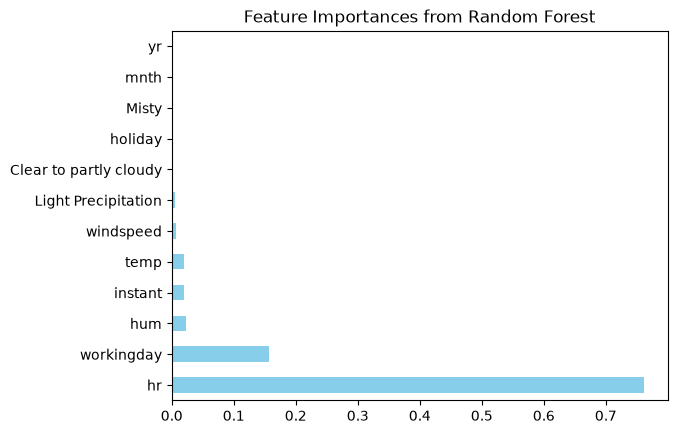

In [98]:
# Visualizing feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

sorted_importances = importances.sort_values(ascending=False)

# Draw barplot
sorted_importances.plot(kind='barh', color='skyblue')
plt.title("Feature Importances from Random Forest")
plt.show()

### Boosting

#### AdaBoost

In [4]:
# Load data
import pandas as pd
from sklearn.model_selection import train_test_split
patient_df = pd.read_csv("data/indian_liver_patient_preprocessed.csv")

X = patient_df.drop(columns=["Liver_disease"]).values
y = patient_df["Liver_disease"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [7]:
# Import DecisionTreeClassifier and AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

dt = DecisionTreeClassifier(max_depth=2, random_state=1)
ada = AdaBoostClassifier(estimator=dt, n_estimators=180, random_state=1)

In [8]:
ada.fit(X_train, y_train)
y_pred_proba = ada.predict_proba(X_test)[:, 1]

In [9]:
# Import roc auc score
from sklearn.metrics import roc_auc_score

ada_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AdaBoost ROC AUC Score: {ada_roc_auc:.4f}")

AdaBoost ROC AUC Score: 0.6897


#### Gradient Boosting

In [19]:
# Get bike data
bike = pd.read_csv("data/bike.csv")

X = bike.drop("cnt", axis=1)
y = bike["cnt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [20]:
# Import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=2)

In [21]:
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

In [23]:
# Import mean_squared_error
from sklearn.metrics import mean_squared_error
import numpy as np

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
print(f"RMSE (Gradient Boosting): {rmse_test:.4f}")

RMSE (Gradient Boosting): 42.7931


#### Stochastic Gradient Boosting

In [24]:
# To use stochastic gradient boosting, set the subsample parameter to a value less than 1.0.
# For example, subsample=0.8 will use 80% of the training data for each tree.

from sklearn.ensemble import GradientBoostingRegressor

sgbr = GradientBoostingRegressor(n_estimators=200, max_features=0.75, subsample=0.9, random_state=2)

sgbr.fit(X_train, y_train)
y_pred = sgbr.predict(X_test)

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
print(f"RMSE (Stochastic Gradient Boosting): {rmse_test:.4f}")

RMSE (Stochastic Gradient Boosting): 50.8162


In [25]:
# Tune hyperparameters using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_features': [0.5, 0.75, 1.0],
    'subsample': [0.8, 0.9, 1.0] # subsample = 1 means no stochastic gradient boosting
}

# Create a GradientBoostingRegressor instance
gb = GradientBoostingRegressor(random_state=2)
gb = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the model to the training data
gb.fit(X_train, y_train)

# Get the best parameters and best score
best_params = gb.best_params_
best_score = np.sqrt(-gb.best_score_)  # Convert negative MSE to RMSE
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validated RMSE: {best_score:.4f}")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_features': 1.0, 'n_estimators': 300, 'subsample': 0.8}
Best Cross-Validated RMSE: 47.9512


### Model Tuning

#### Tuning a CART's hyperparameters

CART : Classification and Regression Trees

##### Tree Hyperparameters

In [26]:
# Load data
import pandas as pd
from sklearn.model_selection import train_test_split
patient_df = pd.read_csv("data/indian_liver_patient_preprocessed.csv")

X = patient_df.drop(columns=["Liver_disease"]).values
y = patient_df["Liver_disease"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [32]:
# Import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

# Check the default hyperparameters of the DecisionTreeClassifier
print(dt.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [47]:
# Define the parameter grid
params_dt = {
    'max_depth': [None, 2, 4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [0.12, 0.14, 0.16, 0.18],
    'criterion': ['gini', 'entropy']
}

In [48]:
# Search for the best hyperparameters using GridSearchCV
from sklearn.model_selection import GridSearchCV

grid_dt = GridSearchCV(estimator=dt, param_grid=params_dt, cv=5, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 2, ...], 'min_samples_leaf': [0.12, 0.14, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [49]:
# Import roc_auc_score
from sklearn.metrics import roc_auc_score

best_model = grid_dt.best_estimator_

y_pred_proba = best_model.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test ROC AUC Score (Best Decision Tree): {test_roc_auc:.4f}")

Test ROC AUC Score (Best Decision Tree): 0.7308


In [50]:
# Check best hyperparameters
best_params = grid_dt.best_params_
print(f"Best Hyperparameters: {best_params}")

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 0.14, 'min_samples_split': 2}


##### Tuning an RF's hyperparameters


In [80]:
# Get bike data
bike = pd.read_csv("data/bike.csv")

X = bike.drop("cnt", axis=1)
y = bike["cnt"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [81]:
# Import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

# Check the default hyperparameters of the RandomForestRegressor
print(rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [69]:
# Define parameter grid for Random Forest
params_rf = {
    'n_estimators': [100, 350, 500],
    'max_depth': [None, 2, 4, 6, 8],
    'min_samples_leaf': [2, 10, 30],
    'max_features': ['log2', 'sqrt', None]
}

In [70]:
grid_rf = GridSearchCV(estimator=rf, param_grid=params_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 135 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 2, ...], 'max_features': ['log2', 'sqrt', ...], 'min_samples_leaf': [2, 10, ...], 'n_estimators': [100, 350, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :

In [78]:
from sklearn.metrics import mean_squared_error as MSE

best_model_rf = grid_rf.best_estimator_
y_pred = best_model_rf.predict(X_test)
rmse_test = MSE(y_test, y_pred) ** (1/2)
print(f"RMSE (Best Random Forest): {rmse_test:.4f}")

RMSE (Best Random Forest): 51.2843


In [79]:
# Best parameters for Random Forest
best_params_rf = grid_rf.best_params_
print(f"Best Hyperparameters (Random Forest): {best_params_rf}")

Best Hyperparameters (Random Forest): {'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'n_estimators': 500}
